In [18]:
%matplotlib inline
%config InlineBackend.figure_formats="retina"

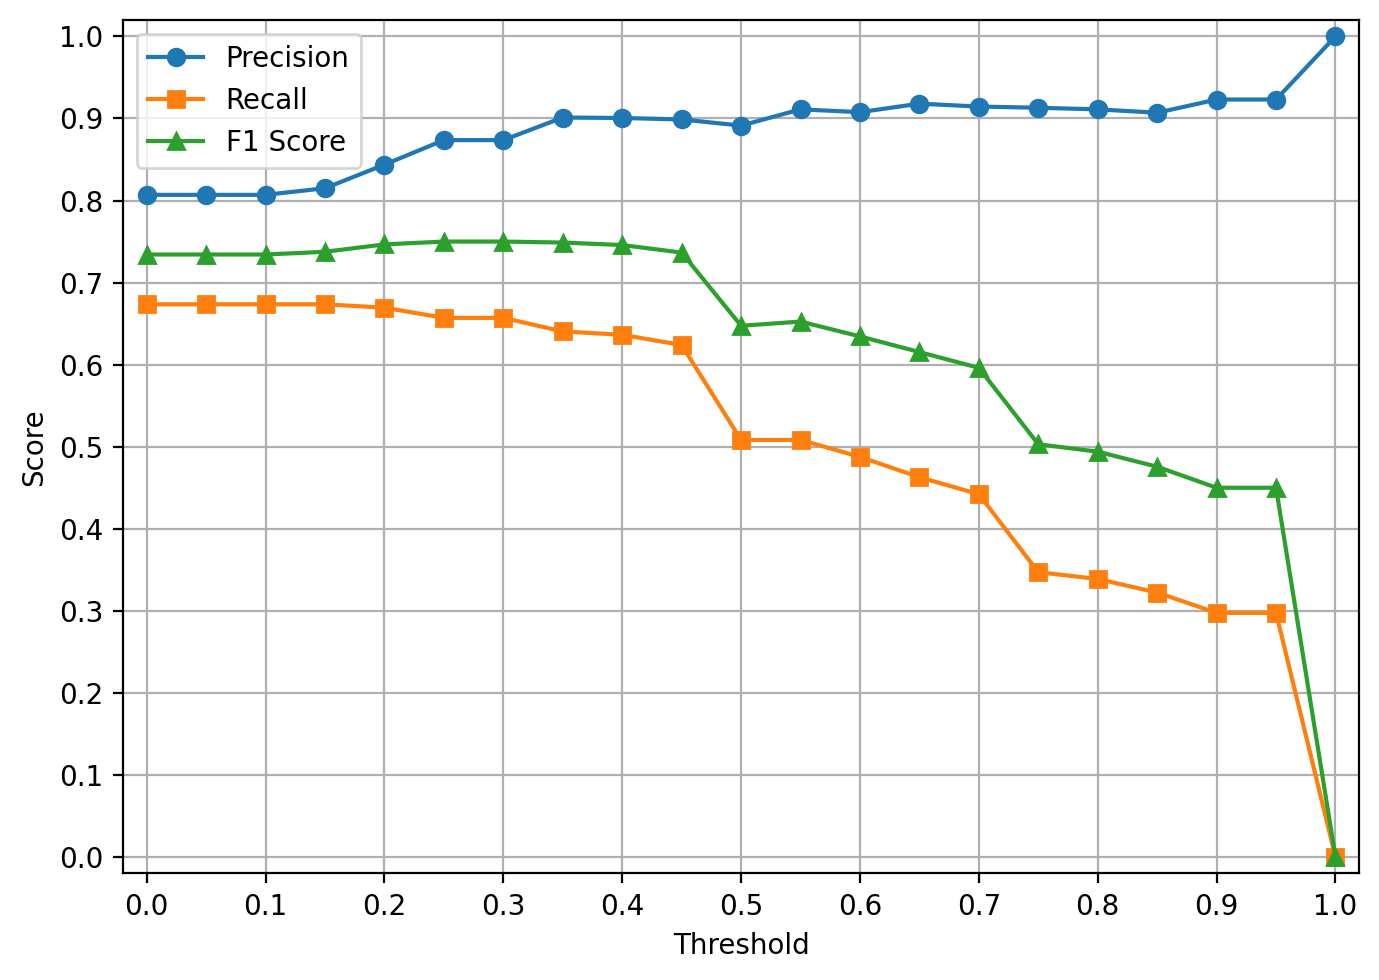

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from evaluation import match, calculate_f1, classify_by_thresh


def pr_curve(lang: str, feature_cols: list[str], params: list[float]):
    df = pd.read_csv(f"../benchmark/ground_truth/{lang}_ground_truth.csv")
    phantom_pairs = None
    phantom_pairs = pd.read_csv(
        f"../benchmark/ground_truth/{lang}_validation_results.csv"
    )
    phantom_pairs = phantom_pairs[~phantom_pairs["validation"]][
        ["record_id", "old_index", "new_index"]
    ]
    df["score"] = sum(df[feature_cols[i]] * params[i] for i in range(len(feature_cols)))
    df["index_sim"] = abs(df["old_index"] - df["new_index"])
    matched_df = match(df)
    precisions, recalls, thresholds, f1s = [], [], [], []
    for thresh in np.linspace(0.0, 1.0, 21):
        f1, p, r = calculate_f1(classify_by_thresh(matched_df, thresh, phantom_pairs))
        # print(f"{thresh}: {p} {r} {f1}")
        thresholds.append(thresh)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(thresholds, precisions, label="Precision", marker="o")
    ax.plot(thresholds, recalls, label="Recall", marker="s")
    ax.plot(thresholds, f1s, label="F1 Score", marker="^")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    params_str = "_".join([str(p) for p in params])
    fig.savefig(f"../figs/{lang}_pr_{params_str}.pdf")
    return pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precisions,
            "recall": recalls,
            "f1_socre": f1s,
        }
    )


res = pr_curve("py", ["fqn_sim", "arg_sim"], [0.5, 0.5])

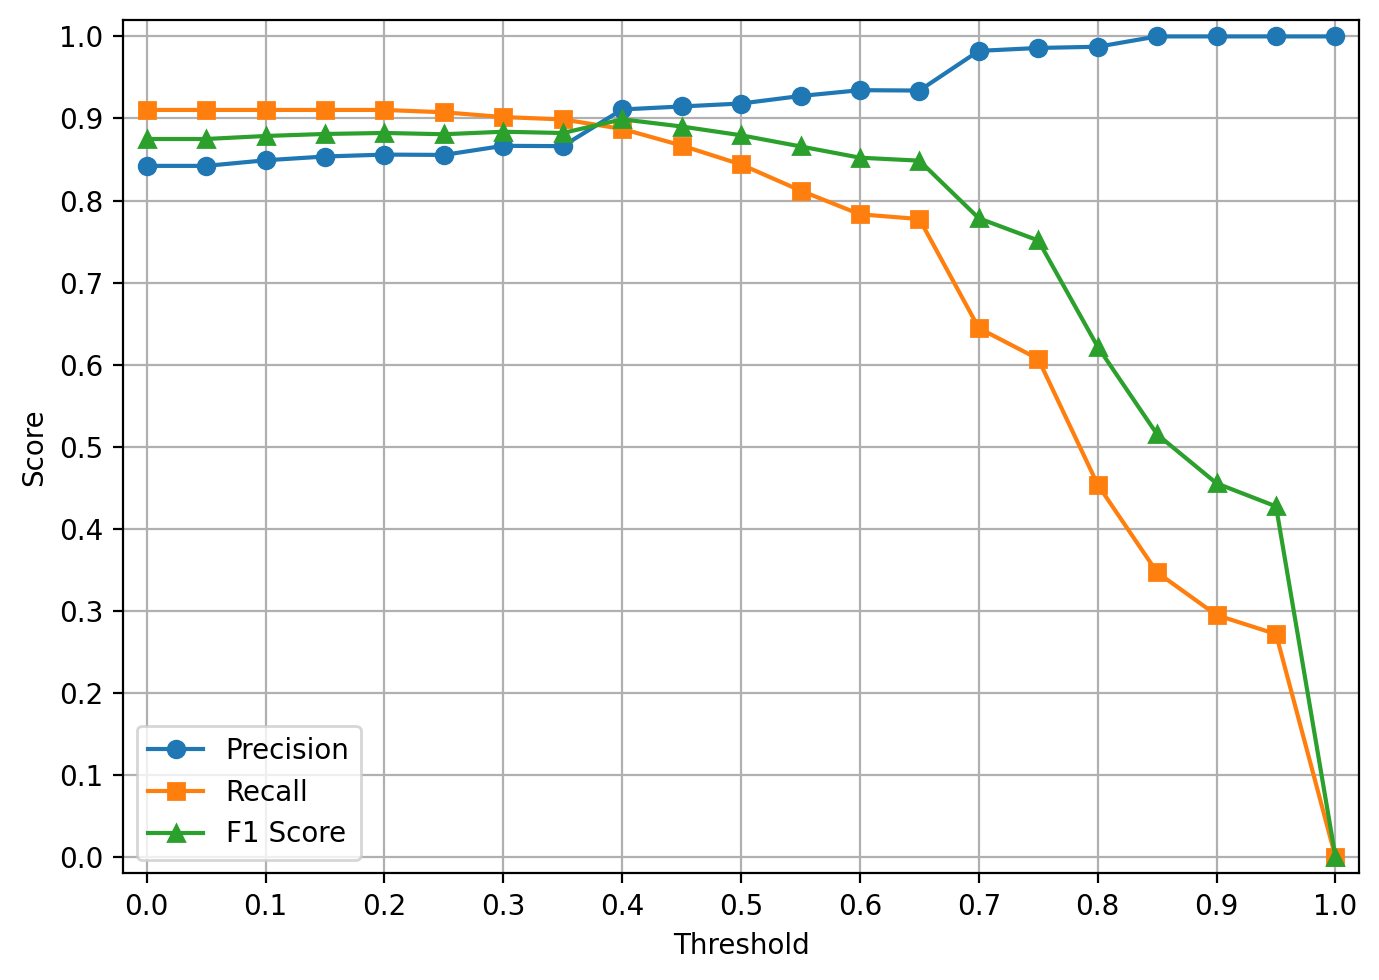

In [27]:
res = pr_curve("java", ["class_sim", "method_sim", "arg_sim"], [0.4, 0.3, 0.3])